📈 𝙈𝙖𝙘𝙝𝙞𝙣𝙚 𝙇𝙚𝙖𝙧𝙣𝙞𝙣𝙜 𝙛𝙤𝙧 𝙎𝙩𝙤𝙘𝙠 𝙈𝙖𝙧𝙠𝙚𝙩 𝙋𝙧𝙚𝙙𝙞𝙘𝙩𝙞𝙤𝙣 🤖


Step 1: Import libraries

In [42]:
# Step 1:import libraries
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import joblib



Setup and Upload Data

In [43]:
# Upload file
uploaded = files.upload()

# Load the dataset (adjust filename if needed)
df = pd.read_csv('aapl_2014_2023.csv')

# Display first few rows
print("First 5 rows:")
print(df.head())

# Check data types and missing values
print("\nData info:")
print(df.info())

Saving aapl_2014_2023.csv to aapl_2014_2023.csv
First 5 rows:
         date       open       high        low      close     volume  \
0  02/01/2014  19.845715  19.893929  19.715000  19.754642  234684800   
1  03/01/2014  19.745001  19.775000  19.301071  19.320715  392467600   
2  06/01/2014  19.194643  19.528570  19.057142  19.426071  412610800   
3  07/01/2014  19.440001  19.498571  19.211430  19.287144  317209200   
4  08/01/2014  19.243214  19.484285  19.238930  19.409286  258529600   

       rsi_7     rsi_14       cci_7      cci_14     sma_50     ema_50  \
0  44.149614  50.996175 -105.071637  -42.411877  19.282236  19.265060   
1  33.094332  43.883529 -152.150999 -124.511983  19.297314  19.267243   
2  37.525661  45.858019 -132.306490 -130.122350  19.310864  19.273472   
3  34.055624  43.675708  -89.587009 -108.089019  19.316671  19.274008   
4  39.768497  46.104107  -58.525539  -82.150032  19.329171  19.279313   

     sma_100    ema_100      macd  bollinger  TrueRange     atr_7 

Step 2: Data Preprocessing

Training samples: 2012, Test samples: 504

First 10 rows of X_train:
 [[ 0]
 [ 1]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [11]
 [12]
 [13]]
First 10 rows of y_train:
 [19.754642 19.320715 19.426071 19.287144 19.409286 19.161428 19.033571
 19.133215 19.513929 19.905714]

First 10 rows of X_test:
 [[2918]
 [2919]
 [2920]
 [2923]
 [2924]
 [2925]
 [2926]
 [2927]
 [2930]
 [2931]]
First 10 rows of y_test:
 [179.380005 178.199997 177.570007 182.009995 179.699997 174.919998
 172.       172.169998 172.190002 175.080002]


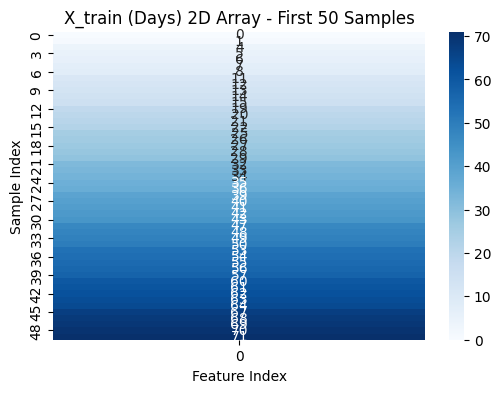

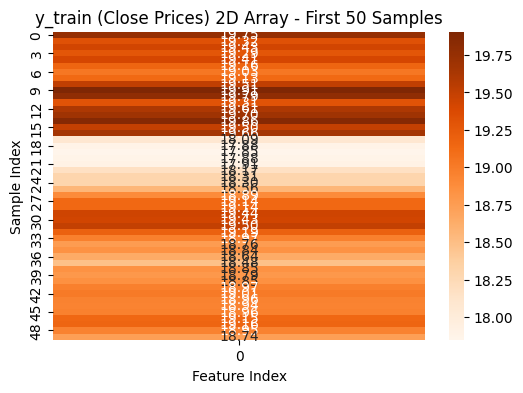

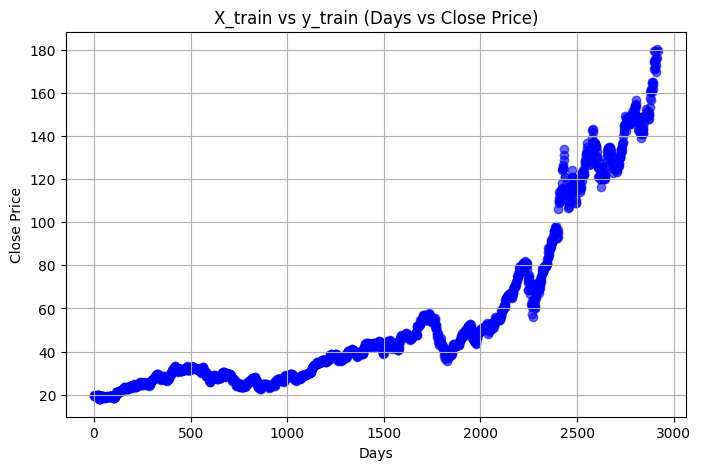

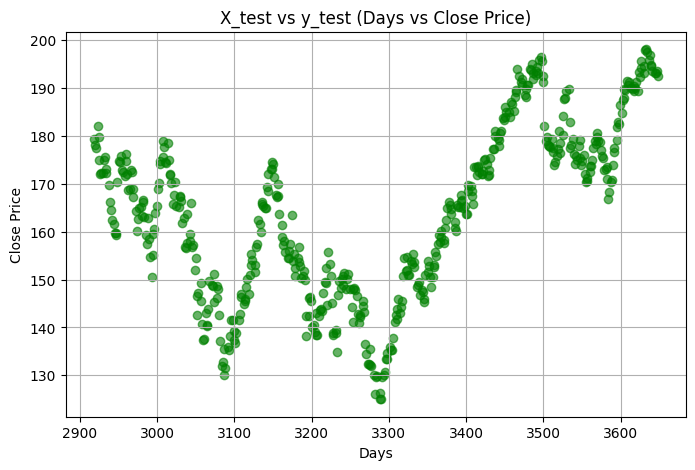

In [44]:
# Step 2: Preprocessing + Visualization

# -----------------------------
# Original Preprocessing Code
# -----------------------------
# Convert Date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Sort by date (important for time series)
df = df.sort_values('date')

# Create numeric feature: number of days since the first date
df['Days'] = (df['date'] - df['date'].min()).dt.days

# Use Days as feature (X) and 'Close' price as target (y)
X = df[['Days']].values  # 2D array
y = df['close'].values   # 1D array

# Train-test split (preserve time order)
split_index = int(0.8 * len(df))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Print training and test sample counts
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

# -----------------------------
# Print sample values
# -----------------------------
print("\nFirst 10 rows of X_train:\n", X_train[:10])
print("First 10 rows of y_train:\n", y_train[:10])
print("\nFirst 10 rows of X_test:\n", X_test[:10])
print("First 10 rows of y_test:\n", y_test[:10])

# -----------------------------
# Visualization of 2D arrays
# -----------------------------

# Heatmap of X_train (first 50 rows for readability)
plt.figure(figsize=(6,4))
sns.heatmap(X_train[:50], annot=True, fmt=".0f", cmap="Blues")
plt.title("X_train (Days) 2D Array - First 50 Samples")
plt.xlabel("Feature Index")
plt.ylabel("Sample Index")
plt.show()

# Heatmap of y_train (reshape temporarily to 2D for heatmap)
plt.figure(figsize=(6,4))
sns.heatmap(y_train[:50].reshape(-1,1), annot=True, fmt=".2f", cmap="Oranges")
plt.title("y_train (Close Prices) 2D Array - First 50 Samples")
plt.xlabel("Feature Index")
plt.ylabel("Sample Index")
plt.show()

# Scatter plot: X_train vs y_train
plt.figure(figsize=(8,5))
plt.scatter(X_train[:,0], y_train, color='blue', alpha=0.6)
plt.title("X_train vs y_train (Days vs Close Price)")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

# Scatter plot: X_test vs y_test
plt.figure(figsize=(8,5))
plt.scatter(X_test[:,0], y_test, color='green', alpha=0.6)
plt.title("X_test vs y_test (Days vs Close Price)")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

Step 3: Train Linear Regression

In [45]:
# Step 3: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict on the entire dataset for plotting
y_lin_pred = lin_reg.predict(X)

# Evaluate on test set
y_test_lin = lin_reg.predict(X_test)
lin_rmse = np.sqrt(mean_squared_error(y_test, y_test_lin))
lin_r2 = r2_score(y_test, y_test_lin)
print(f"Linear Regression - RMSE: {lin_rmse:.2f}, R2: {lin_r2:.4f}")

Linear Regression - RMSE: 36.76, R2: -3.3291


Step 3: Linear Regression
Train a linear regression model and visualize predictions on test data.

Linear Regression - MSE: 1351.64, R2: -3.329


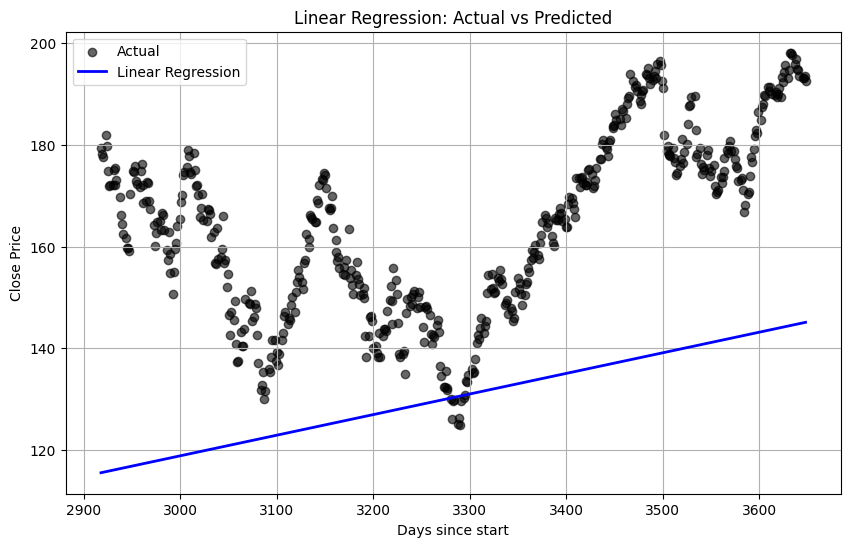

' A scatter plot of actual test points (black) with the \n linear regression line (blue).'

In [46]:
# Step 3: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict on test set
y_pred_lin = lin_reg.predict(X_test)

# Evaluate
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)
print(f"Linear Regression - MSE: {mse_lin:.2f}, R2: {r2_lin:.3f}")

# Plot actual vs predicted (Linear Regression)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='black', label='Actual', alpha=0.6)
plt.plot(X_test, y_pred_lin, color='blue', linewidth=2, label='Linear Regression')
plt.xlabel('Days since start')
plt.ylabel('Close Price')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()
# Evaluation metrics printed.
''' A scatter plot of actual test points (black) with the
 linear regression line (blue).'''



Step 4: Polynomial Regression




Evaluation metrics printed.

Scatter plot of actual test points with the polynomial regression curve (red).

Polynomial Regression (deg=3) - MSE: 11791.56, R2: -36.767


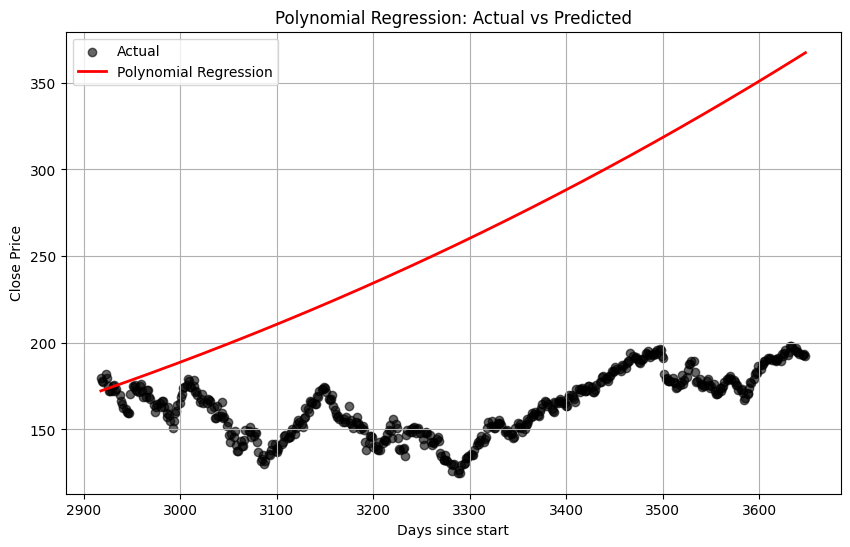

In [47]:
# Step 4: Polynomial Regression
poly_degree = 3
poly_features = PolynomialFeatures(degree=poly_degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# Predict
y_pred_poly = poly_reg.predict(X_test_poly)

# Evaluate
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Polynomial Regression (deg={poly_degree}) - MSE: {mse_poly:.2f}, R2: {r2_poly:.3f}")

# Plot actual vs predicted (Polynomial Regression)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='black', label='Actual', alpha=0.6)
# Need to sort X_test for smooth curve (because polynomial order)
sorted_idx = np.argsort(X_test.flatten())
plt.plot(X_test[sorted_idx], y_pred_poly[sorted_idx], color='red', linewidth=2, label='Polynomial Regression')
plt.xlabel('Days since start')
plt.ylabel('Close Price')
plt.title('Polynomial Regression: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

Step 5: Both Models on Same Graph

Plot both linear (blue) and polynomial (red) predictions together with actual data.

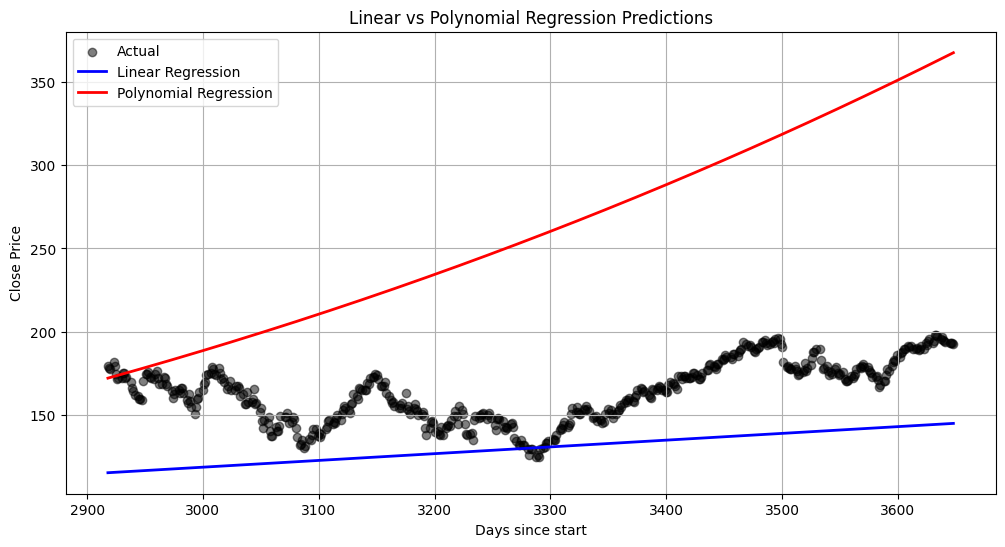

In [48]:
# Step 5: Combined plot
plt.figure(figsize=(12, 6))
plt.scatter(X_test, y_test, color='black', label='Actual', alpha=0.5)
plt.plot(X_test, y_pred_lin, color='blue', linewidth=2, label='Linear Regression')
# For polynomial, sort X for smooth curve
sorted_idx = np.argsort(X_test.flatten())
plt.plot(X_test[sorted_idx], y_pred_poly[sorted_idx], color='red', linewidth=2, label='Polynomial Regression')
plt.xlabel('Days since start')
plt.ylabel('Close Price')
plt.title('Linear vs Polynomial Regression Predictions')
plt.legend()
plt.grid(True)
plt.show()

# Combined graph showing actual data (black dots), linear fit (blue line),
# and polynomial fit (red curve).

Step 6: Save Models as .pkl Files


In [51]:
# Save linear model
joblib.dump(lin_reg, 'linear_model.pkl')

# Save polynomial transformer and model
joblib.dump(poly_features, 'poly_features.pkl')
joblib.dump(poly_reg, 'poly_model.pkl')

# Save degree for reference
with open('poly_degree.txt', 'w') as f:
    f.write(str(poly_degree))

print("Models saved. Downloading files...")
files.download('linear_model.pkl')
files.download('poly_features.pkl')
files.download('poly_model.pkl')
files.download('poly_degree.txt')

Models saved. Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Step 7: Create predict.py

In [58]:
# Step 7: Create predict.py script
predict_code = """# predict.py


# Load saved models
lin_reg = joblib.load('linear_model.pkl')
poly_features = joblib.load('poly_features.pkl')
poly_reg = joblib.load('poly_model.pkl')

with open('poly_degree.txt', 'r') as f:
    degree = int(f.read())
print(f"Loaded polynomial degree: {degree}")

# Example: predict for days 3000, 3001, 3002, 3003, 3004
X_new = np.array([[3000], [3001], [3002], [3003], [3004]])

# Linear predictions
y_lin = lin_reg.predict(X_new)
print("Linear predictions:", y_lin.flatten())

# Polynomial predictions
X_new_poly = poly_features.transform(X_new)
y_poly = poly_reg.predict(X_new_poly)
print(f"Polynomial predictions (deg={degree}):", y_poly.flatten())
"""

with open('predict.py', 'w') as f:
    f.write(predict_code)

print("predict.py created successfully.")
files.download('predict.py')

predict.py created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Step 8: Create README.md

In [59]:
# Step 8: Create README.md
readme_content = """# AAPL Stock Price Prediction (2014–2023)

This project uses Linear Regression and Polynomial Regression to predict Apple Inc. (AAPL) closing prices based on a simple time feature (days since the start of the dataset). Models are trained on historical data from 2014 to 2023 and saved as `.pkl` files for easy reuse.

## Repository Contents

- `linear_model.pkl` – trained Linear Regression model
- `poly_features.pkl` – PolynomialFeatures transformer (degree 3)
- `poly_model.pkl` – trained Polynomial Regression model
- `poly_degree.txt` – degree used for polynomial features
- `predict.py` – example script to load models and make predictions
- `README.md` – this file

## Requirements

- Python 3.6+
- NumPy
- scikit-learn
- joblib

Install dependencies with:

```bash
pip install numpy scikit-learn joblib
```
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md created successfully.")
files.download('README.md')

README.md created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
# https://github.com/ashii94/aaple-stock-prediction.git